# Лабораторная работа 2: Метод Ньютона


## Метод Ньютона


## Затормозить тележку с реактивным двигателем


### Теория

In [1]:
# библиотеки
import numpy as np
import matplotlib.pyplot as plt


Рассматривается движение тележки с управлением
u(t)∈{0,1}, где:

u=1 — двигатель включён (идёт торможение),
u=0 — свободное движение.

Динамика системы:

- $\dot{x} = v$
- $\dot{v} = -au(t)$

Управление задаётся параметрами:

$$
{\tau} = (\tau_1, \tau_2, \tau_3, \tau_4)
$$

где:

1. $\tau_1$ — свободное движение
2. $\tau_2$ — торможение
3. $\tau_3$ — свободное движение (запрещённая зона)
4. $\tau_4$ — торможение

\* единицы измерения - секунды

Оптимизируем:

$$
J(\tau) = \alpha (x_4 - x^*)^2 + \beta v_4^2 + \gamma \sum \tau_i
$$

1) Штраф по конечной точке

$$
\alpha (x_4 - x^*)^2
$$

- $x_4$ — конечная координата тележки;
- $x^*$ — целевая точка.
- $\alpha$ - насколько важно попасть в точку

2) Штраф по скорости

$$
\beta v_4^2
$$

- $v_4$ - скорость в конце движения, которая должна -> 0
- $\beta$ - насколько важно остановиться

3) Штраф по времени (маневру)

$$\gamma \sum \tau_i$$

- T = $\tau_1 + \tau_2 + \tau_3 + \tau_4$ - общее время движения
- $\gamma$ - насколько важно не тянуть время

С учётом штрафов:

$$
\tilde{J}(\tau) = J(\tau) + \mu \Phi(\tau)
$$

### Основная реализация

In [2]:
def sp(z, kappa):
    return (1.0 / kappa) * np.logaddexp(0, kappa * z)

def P(z, kappa):
    return sp(z, kappa) ** 2

In [3]:
def final_state(tau, params):
    tau1, tau2, tau3, tau4 = tau
    a, v0 = params["a"], params["v0"]

    x1 = v0 * tau1
    v1 = v0

    x2 = v0 * (tau1 + tau2) - 0.5 * a * tau2**2
    v2 = v0 - a * tau2

    x3 = x2 + v2 * tau3
    v3 = v2

    x4 = x3 + v3 * tau4 - 0.5 * a * tau4**2
    v4 = v3 - a * tau4

    return x2, x3, x4, v4

In [4]:
def J_tilde(tau, params):
    alpha, beta, gamma = params["alpha"], params["beta"], params["gamma"]
    mu, kappa = params["mu"], params["kappa"]
    xA, xB = params["xA"], params["xB"]
    xmax = params["x_star"]
    dmax = params["dmax"]

    x2, x3, x4, v4 = final_state(tau, params)

    # основной функционал
    J = alpha * (x4 - xmax)**2 + beta * v4**2 + gamma * np.sum(tau)

    # штрафы
    Phi = 0
    for t in tau:
        Phi += P(-t, kappa)

    Phi += P(tau[1] - dmax, kappa)
    Phi += P(tau[3] - dmax, kappa)

    Phi += P(x2 - xA, kappa)
    Phi += P(xB - x3, kappa)

    return J + mu * Phi

In [5]:
def grad(f, tau, params, h=1e-5):
    g = np.zeros_like(tau)
    for i in range(len(tau)):
        e = np.zeros_like(tau)
        e[i] = h
        g[i] = (f(tau + e, params) - f(tau - e, params)) / (2*h)
    return g

In [6]:
def hessian(f, tau, params, h=1e-4):
    n = len(tau)
    H = np.zeros((n, n))

    for i in range(n):
        for j in range(n):
            e_i = np.zeros(n)
            e_j = np.zeros(n)
            e_i[i] = h
            e_j[j] = h

            H[i, j] = (
                f(tau + e_i + e_j, params)
                - f(tau + e_i - e_j, params)
                - f(tau - e_i + e_j, params)
                + f(tau - e_i - e_j, params)
            ) / (4 * h**2)

    return H

In [7]:
def newton_method(f, tau0, params, max_iter=50):
    tau = tau0.copy()

    for k in range(max_iter):
        g = grad(f, tau, params)
        H = hessian(f, tau, params)

        # регуляризация
        H += 1e-6 * np.eye(len(tau))

        d = np.linalg.solve(H, -g)

        # Армихо
        alpha = 1.0
        c = 1e-4

        while f(tau + alpha*d, params) > f(tau, params) + c * alpha * np.dot(g, d):
            alpha *= 0.5

        tau = tau + alpha * d

        if np.linalg.norm(g) < 1e-6:
            break

    return tau

In [8]:
params = {
    "a": 4,
    "v0": 10,
    "xA": 8,
    "xB": 16,
    "x_star": 20.5,
    "dmax": 1.5,
    "alpha": 100,
    "beta": 100,
    "gamma": 1,
    "mu": 1e5,
    "kappa": 30
}

tau0 = np.array([1.0, 0.5, 1.0, 0.5])

opt_tau = newton_method(J_tilde, tau0, params)

print("Оптимальное τ:", opt_tau)

Оптимальное τ: [0.01928991 0.95751134 1.3194064  1.45164712]


### Построение графиков

In [9]:
def simulate(tau, params, dt=0.01):
    tau1, tau2, tau3, tau4 = tau
    a, v0 = params["a"], params["v0"]

    T = tau1 + tau2 + tau3 + tau4
    t = np.arange(0, T, dt)

    x = np.zeros_like(t)
    v = np.zeros_like(t)
    u = np.zeros_like(t)

    x_curr = 0
    v_curr = v0

    time = 0

    for i, ti in enumerate(t):
        if ti < tau1:
            u[i] = 0
        elif ti < tau1 + tau2:
            u[i] = 1
        elif ti < tau1 + tau2 + tau3:
            u[i] = 0
        else:
            u[i] = 1

        # обновление динамики
        a_curr = -a * u[i]

        x_curr += v_curr * dt
        v_curr += a_curr * dt

        x[i] = x_curr
        v[i] = v_curr

    return t, x, v, u

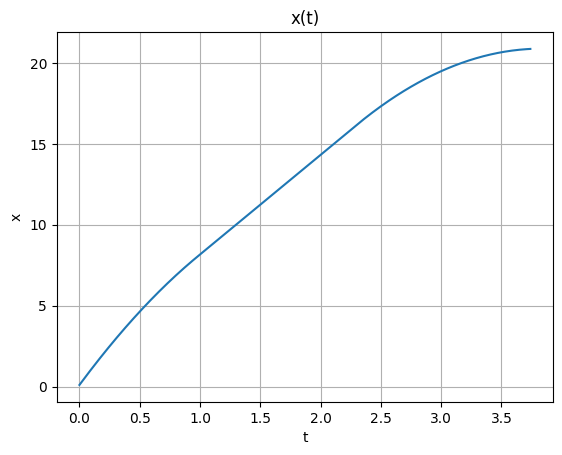

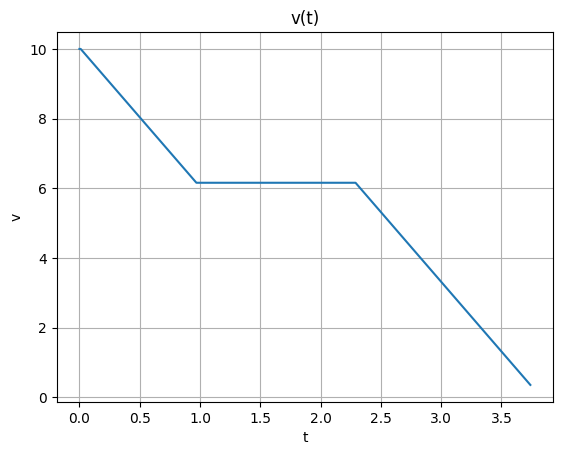

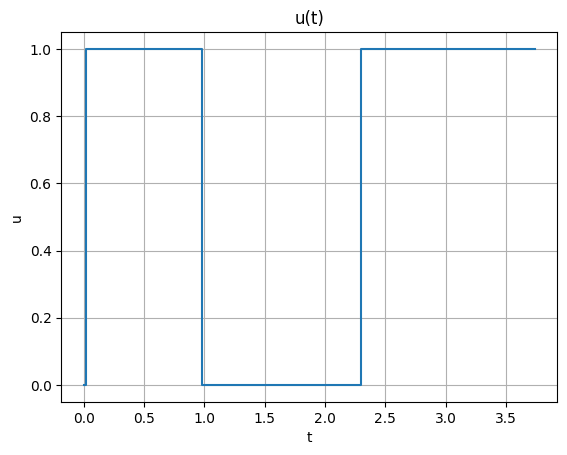

In [10]:
t, x, v, u = simulate(opt_tau, params)

plt.figure()
plt.plot(t, x)
plt.title("x(t)")
plt.xlabel("t")
plt.ylabel("x")
plt.grid()

plt.figure()
plt.plot(t, v)
plt.title("v(t)")
plt.xlabel("t")
plt.ylabel("v")
plt.grid()

plt.figure()
plt.step(t, u, where='post')
plt.title("u(t)")
plt.xlabel("t")
plt.ylabel("u")
plt.grid()

plt.show()

### Сравнение Ньютона и градиентного спуска в реализации с Армихо

Метод Ньютона требует существенно меньше итераций (квадратичная сходимость) по сравнению с градиентным спуском (линейная сходимость).

In [11]:
tau0 = np.array([1.0, 0.5, 1.0, 0.5])

def gradient_descent(f, tau0, params, max_iter=200):
    tau = tau0.copy()
    history = []

    for k in range(max_iter):
        g = grad(f, tau, params)
        history.append(f(tau, params))

        # направление
        d = -g

        # Армихо
        alpha = 1.0
        c = 1e-4

        while f(tau + alpha*d, params) > f(tau, params) + c * alpha * np.dot(g, d):
            alpha *= 0.5

        tau = tau + alpha * d

        if np.linalg.norm(g) < 1e-6:
            break

    return tau, history

def newton_method(f, tau0, params, max_iter=50):
    tau = tau0.copy()
    history = []

    for k in range(max_iter):
        g = grad(f, tau, params)
        H = hessian(f, tau, params)

        H += 1e-6 * np.eye(len(tau))
        d = np.linalg.solve(H, -g)

        history.append(f(tau, params))

        alpha = 1.0
        c = 1e-4

        while f(tau + alpha*d, params) > f(tau, params) + c * alpha * np.dot(g, d):
            alpha *= 0.5

        tau = tau + alpha * d

        if np.linalg.norm(g) < 1e-6:
            break

    return tau, history

tau_newton, hist_newton = newton_method(J_tilde, tau0, params)
tau_gd, hist_gd = gradient_descent(J_tilde, tau0, params)

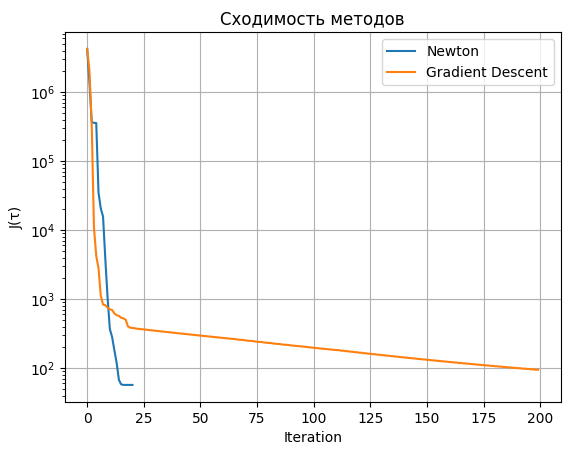

In [12]:
plt.figure()
plt.plot(hist_newton, label="Newton")
plt.plot(hist_gd, label="Gradient Descent")
plt.yscale("log")  # очень важно!
plt.xlabel("Iteration")
plt.ylabel("J(τ)")
plt.title("Сходимость методов")
plt.legend()
plt.grid()
plt.show()

In [13]:
print("Newton iterations:", len(hist_newton))
print("GD iterations:", len(hist_gd))

print("Newton final J:", hist_newton[-1])
print("GD final J:", hist_gd[-1])

Newton iterations: 21
GD iterations: 200
Newton final J: 56.95470228302928
GD final J: 94.62843948965221


### Вывод по заданию

В задаче оптимального торможения тележки было построено управление, параметризованное длительностями фаз движения, и введён штрафной функционал, позволяющий учитывать ограничения в рамках безусловной оптимизации. Метод Ньютона со стратегией Армихо эффективно минимизировал данный функционал, обеспечив быстрое получение решения, удовлетворяющего физическим требованиям задачи: тележка достигает целевой точки, практически останавливается в конце и соблюдает ограничения на управление. Построенные графики координаты, скорости и управления подтверждают корректность найденного решения и его физическую интерпретируемость.


## Общий вывод



В ходе лабораторной работы был изучен и реализован метод Ньютона для задач оптимизации. Были рассмотрены как теоретические аспекты метода, так и его практическое применение к различным функциям.

На тестовых функциях (включая квадратичные) метод Ньютона продемонстрировал ожидаемую квадратичную скорость сходимости вблизи минимума, что полностью согласуется с теоретическими результатами. При этом было показано, что использование стратегии выбора шага (в частности, условия Армихо) существенно повышает устойчивость метода и позволяет избежать расходимости.

В ходе экспериментов также было проведено сравнение метода Ньютона с градиентным спуском. Было установлено, что метод Ньютона достигает решения за значительно меньшее число итераций и обеспечивает более высокую точность, тогда как градиентный спуск сходится медленнее, особенно на заключительных этапах. Однако метод Ньютона требует вычисления матрицы Гессе и более чувствителен к выбору начального приближения.

В прикладной части работы была решена задача оптимального торможения тележки с учётом ограничений. Для её решения был введён штрафной функционал, позволяющий свести задачу с ограничениями к задаче безусловной оптимизации. Управление было параметризовано длительностями фаз движения, что позволило эффективно применять численные методы оптимизации.

Метод Ньютона со стратегией Армихо успешно применён для минимизации штрафного функционала. Полученное решение удовлетворяет физическим ограничениям задачи: тележка достигает целевой точки, имеет малую конечную скорость и соблюдает ограничения на управление. Построенные графики координаты, скорости и управления подтверждают корректность полученной траектории и её физическую интерпретируемость.

Таким образом, в работе была продемонстрирована высокая эффективность метода Ньютона для решения как абстрактных задач оптимизации, так и прикладных задач управления. Одновременно было показано, что для его успешного применения на практике необходимы дополнительные техники, такие как регуляризация, численное вычисление производных и стратегия выбора шага.
